<a href="https://colab.research.google.com/github/harirkp006/MLOPS-TRAINING/blob/main/onehot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

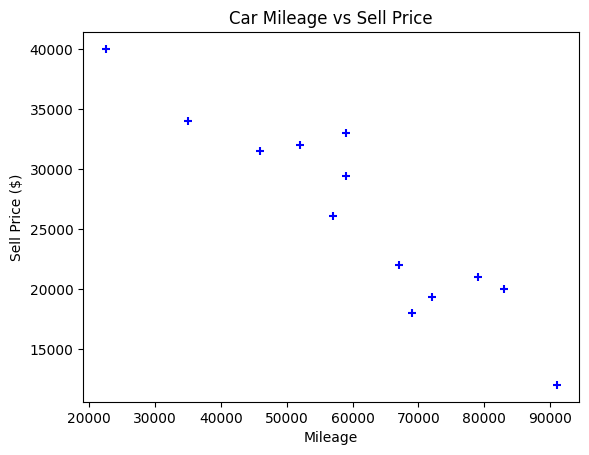

------------------------------------------------------------------


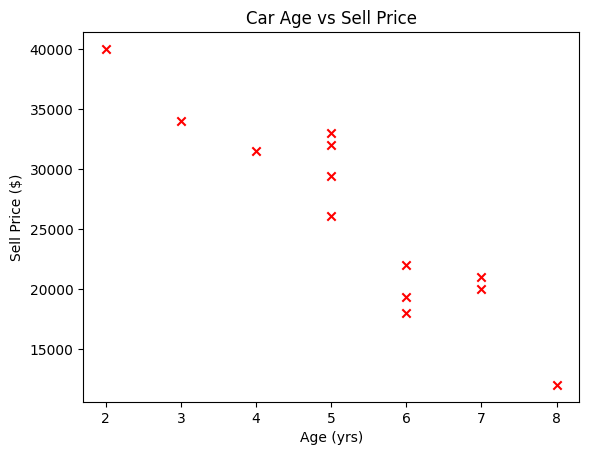


Final Formatted Dataset:
   Mileage  Sell Price($)  Age(yrs)  Audi A5  BMW X5
0    69000          18000         6        0       1
1    35000          34000         3        0       1
2    57000          26100         5        0       1
3    22500          40000         2        0       1
4    46000          31500         4        0       1

Feature Columns Order in X:
['Mileage', 'Age(yrs)', 'Audi A5', 'BMW X5']

3) Model Accuracy Score (R^2): 0.9417 (or 94.17%)
------------------------------------------------------
1) Predicted Price of a 4yr old Mercedes Benz (45k Mileage): $36,991.32
-------------------------------------------------------
Predicted Price of a 7yr old BMW X5: $11,080.74


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = pd.read_csv("/content/carprices.csv")

plt.scatter(df['Mileage'], df['Sell Price($)'], color='blue', marker='+')
plt.title('Car Mileage vs Sell Price')
plt.xlabel('Mileage')
plt.ylabel('Sell Price ($)')
plt.savefig('mileage_vs_price.png')
plt.show()
print("------------------------------------------------------------------")
plt.scatter(df['Age(yrs)'], df['Sell Price($)'], color='red', marker='x')
plt.title('Car Age vs Sell Price')
plt.xlabel('Age (yrs)')
plt.ylabel('Sell Price ($)')
plt.savefig('age_vs_price.png')
plt.show()

dummy = pd.get_dummies(df['Car Model']).astype(int)
merged = pd.concat([df, dummy], axis='columns')
final = merged.drop(['Car Model', 'Mercedez Benz C class'], axis='columns')

print("\nFinal Formatted Dataset:")
print(final.head())

X = final.drop('Sell Price($)', axis='columns')
y = final['Sell Price($)']

print("\nFeature Columns Order in X:")
print(list(X.columns))

model = LinearRegression()
model.fit(X, y)

accuracy_score = model.score(X, y)
print(f"\n3) Model Accuracy Score (R^2): {accuracy_score:.4f} (or {accuracy_score*100:.2f}%)")
print("------------------------------------------------------")
mercedes_pred = model.predict(pd.DataFrame([[45000, 4, 0, 0]], columns=X.columns))
print(f"1) Predicted Price of a 4yr old Mercedes Benz (45k Mileage): ${mercedes_pred[0]:,.2f}")
print("-------------------------------------------------------")
bmw_pred = model.predict(pd.DataFrame([[86000, 7, 0, 1]], columns=X.columns))
print(f"Predicted Price of a 7yr old BMW X5: ${bmw_pred[0]:,.2f}")